In [2]:
# -----------------------------
# Import libraries
# -----------------------------

from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from xgboost import XGBRegressor
#from tqdm import tqdm
import time
from scipy.stats import uniform
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [3]:
pnw = pd.read_csv(
    "../data/raw/NCASIpollen_raw.csv",
    encoding="latin1",
    low_memory=False
)

# Columns you expect to exist
cols = ["SampleID", "Stand"]

# Keep only columns that are actually present in the CSV
cols = [c for c in cols if c in pnw.columns]

# Collect RBCL columns
rbcl_cols = [c for c in pnw.columns if c.startswith("RBCL:")]

# Subset the dataframe (make a copy to avoid warnings)
pnw_sub = pnw[cols + rbcl_cols].copy()

# Create UniqueID and Site safely
if "SampleID" in pnw_sub.columns:
    pnw_sub["UniqueID"] = pnw_sub["SampleID"]

if "Stand" in pnw_sub.columns:
    pnw_sub["Site"] = pnw_sub["Stand"]

# Final column order
new_cols = [c for c in ["UniqueID", "Site"] if c in pnw_sub.columns]

pnw_final = pnw_sub[new_cols + rbcl_cols]

pnw_final["Project"] = "PNW"

pnw_final.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_18568\856468580.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pnw_final["Project"] = "PNW"


,UniqueID,Site,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,...,RBCL:CTCCTGACTATGAAACCAAAGATATTGCTATCTTGGCAGCATTCTGAGTAACTCCTCAATCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTGGACTGGTACATGAACAACTGTGTGAATCGATAGACATATTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCCGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAGTTGTGTGGACCGATGGGCTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTGGCAGCAATCCGAGTAACTCCTCAACCAGGAGTTCCACCTAAAGAAACAGGGGCCGTGGTAGCGGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTAGCAGCAATCCGAGTAACTCCTCAATCAGGAGTTCCACCTAAAGAAGCAGGGGCCCCGGTAGCGGCGGAATCTTCTCCTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCCGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAGTTGTGTGGACCGATGGGCTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGCGTTCCACCGGAGGAAGCAGGAGCAGCGGTAGCTGCGGAATCTTCTACTGGTACCTGGACAACTGTTTGGACAGATGGACTGACCAGTCTTGATCGTTATAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTAGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGTGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGAAGCAGGGGCCGCAGTAGCCGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTGGCAGCAATCCGAGTAACTCCTCAACCAGGAGTTCCACCTAAAGAAGCAGGGGCCCCGGTAGCGGCGGGATCTTCTACTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,Project
0,NCASI-S63152,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
1,NCASI-S63154,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
2,NCASI-S63138,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
3,NCASI-S63135,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
4,NCASI-S63145,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW


In [4]:
## import data

ca = pd.read_csv("../data/raw/FFARpollen_raw.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in ca.columns if c.startswith("RBCL:")]

ca_sub = ca[cols + rbcl_cols]

ca_sub["Project"] = "CA"
ca_sub.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_18568\567351007.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_sub["Project"] = "CA"


,UniqueID,Site,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCCGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTACGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCAGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTAAAGAAGCGGGGGCCACGATAGCTGCCGAATCTTCTACTGGTACATGGACCACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGAGACTGATATCTTAGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCGGGGGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGTGCAGCGGTAGCTGCCGAATCTTCCACTGGGACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCAGGAGTTCCGCCTGAAGAAGCAGGTGCCGCGGTAGCCGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGTTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,...,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAACGGGGGCCGCGGCAGCTGCCGAATCTTCTACTGGTACATGGGCCACTTTGTGGACCGATGGACTTACCAGCCTCGATCCTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTTATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTATCTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCGGGAGTTCCACCTGAGGAAGCAGGGGCAGCTGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCACCTGAAGAAGCAGAGGCTGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGGCTAAGTTAAAATTTGGCGTTGTTGCGAGTAGAGTCCCCTTTTATTGTGTCAGTACCGTTATTTGCATCACAAGTTAGGCCCTTAGCGTTTGGAAGAGAATACAAATTATACGAACCCTTCGATTTCTCCAAGTCCGTTCGATTTAAAACTGGAGAGGGTGTAGCCGACGACTGGGAAGGCTTCGCTGGTAGCGGAGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAAGTCCGAAACCTGGAGTTCCGGCTGAAGAAGCAGGTGCAGCGGTAGCTGCCGAATCTTCCACTGGGACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAACCTTGATCGTTACAAAGGGCGCTGCTAC,Project
0,SF262,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
1,SF263,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
2,SF261,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
3,SF266,Turk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
4,SF267,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA


In [5]:
## import data

si = pd.read_csv("../data/raw/SIpollen_raw.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in si.columns if c.startswith("RBCL:")]

si_sub = si[cols + rbcl_cols]

si_sub["Project"] = "SI"
si_sub.shape

C:\Users\rah10\AppData\Local\Temp\ipykernel_18568\1279891967.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si_sub["Project"] = "SI"


(19031, 243)

In [6]:
# This will display all columns without truncation.
pd.set_option('display.max_columns', None)

## merging all dataframes for projects
df_merged = (
    pnw_final.merge(si_sub, on=["UniqueID", "Site", "Project"], how="outer")
       .merge(ca_sub, on=["UniqueID", "Site", "Project"], how="outer")
)


In [7]:
import pandas as pd

## combining columns from different datasets with the same id

# Find columns with "_x" suffix
for col in df_merged.columns:
    if col.endswith("_x"):
        base = col[:-2]  # remove "_x"
        col_y = base + "_y"
        
        if col_y in df_merged.columns:
            # Combine the two columns (take max, sum, or first non-null)
            df_merged[base] = df_merged[[col, col_y]].max(axis=1)
            # Drop the old _x and _y columns
            df_merged.drop(columns=[col, col_y], inplace=True)
        else:
            # If no _y column exists, just rename _x to base
            df_merged.rename(columns={col: base}, inplace=True)

# Rename any remaining _y columns (that didn't have _x) to base
for col in df_merged.columns:
    if col.endswith("_y"):
        df_merged.rename(columns={col: col[:-2]}, inplace=True)


In [8]:
rbcl_cols = [c for c in df_merged.columns if c.startswith("RBCL:")]

all_pollen_clean = df_merged.dropna(subset=rbcl_cols, how="all")
all_pollen_clean.shape

(1582, 957)

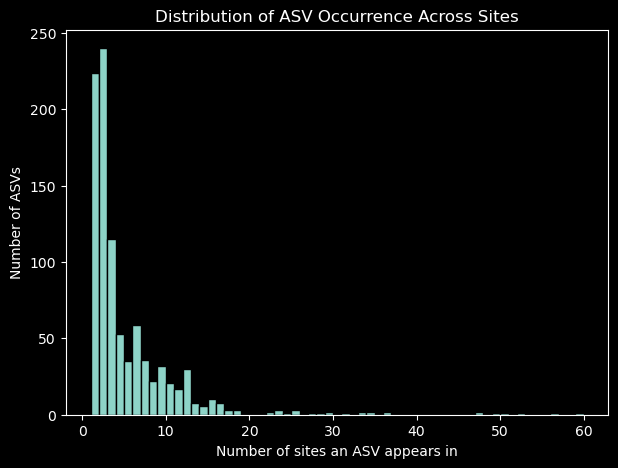

In [10]:
## plotting distribution of ASVs across sites
# Separate metadata and ASV abundance columns
meta_cols = ["UniqueID", "Site", "Project"]  # adjust names as needed
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# Convert relative abundance to presence/absence
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# Count in how many sites each ASV occurs
asv_site_counts = presence.groupby(all_pollen_clean["Site"]).sum().astype(bool).sum(axis=0)

# Plot
plt.figure(figsize=(7,5))
plt.hist(asv_site_counts, bins=range(1, asv_site_counts.max()+2), edgecolor='black')
plt.xlabel("Number of sites an ASV appears in")
plt.ylabel("Number of ASVs")
plt.title("Distribution of ASV Occurrence Across Sites")
plt.show()

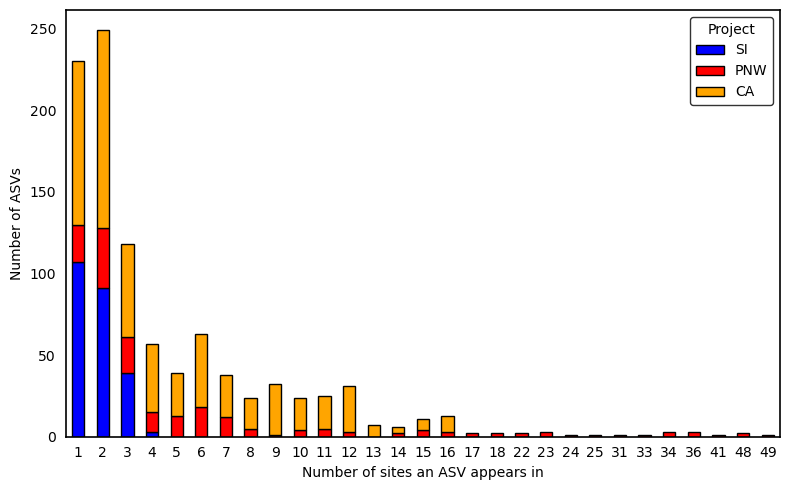

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Separate metadata and ASV columns ---
meta_cols = ["UniqueID", "Site", "Project"]
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# --- 2. Convert relative abundance to presence/absence ---
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# --- 3. Add metadata back ---
presence[meta_cols] = all_pollen_clean[meta_cols]

# --- 4. Count in how many sites each ASV occurs per Project ---
presence_long = presence.melt(
    id_vars=meta_cols, value_vars=asv_cols,
    var_name="ASV", value_name="Presence"
)

# Keep only present (1) entries
presence_long = presence_long[presence_long["Presence"] == 1]

# Count sites per ASV per project
asv_site_counts = (
    presence_long.groupby(["Project", "ASV"])["Site"]
    .nunique()
    .reset_index()
    .rename(columns={"Site": "NumSites"})
)

# --- 5. Histogram table ---
hist_table = asv_site_counts.groupby(["NumSites", "Project"]).size().unstack(fill_value=0)

# --- 6. Color map for projects ---
color_map = {
    "SI": "blue",
    "PNW": "red",
    "CA": "orange"
}

# Reorder columns to ensure colors match your preferred order (if present)
ordered_projects = [p for p in ["SI", "PNW", "CA"] if p in hist_table.columns]

# --- 7. Plot ---
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")

hist_table[ordered_projects].plot(
    kind="bar",
    stacked=True,
    edgecolor='black',
    color=[color_map[p] for p in ordered_projects],
    ax=ax
)

ax.set_xlabel("Number of sites an ASV appears in", color='black')
ax.set_ylabel("Number of ASVs", color='black')
#ax.set_title("Distribution of raw ASV Occurrence Across Sites by Project", color='black')

plt.xticks(rotation=0, color='black')
plt.yticks(color='black')
plt.legend(title="Project")
plt.tight_layout()

# Legend with white background + black text
leg = plt.legend(title="Project")
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('black')

# Set legend text color to black
for text in leg.get_texts():
    text.set_color("black")

# Set legend title color to black
leg.get_title().set_color("black")


# Make axes border lines black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)   # optional: makes the lines a little thicker

plt.show()


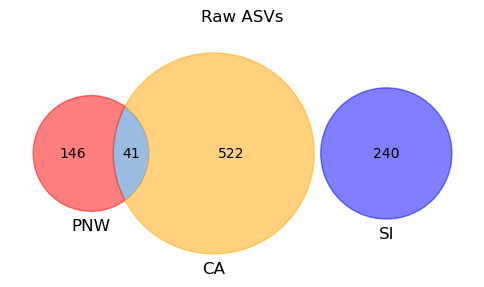

In [16]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# --- 1. Get unique ASVs per project ---
projects = presence_long["Project"].unique()

if len(projects) != 3:
    raise ValueError("There must be exactly 3 projects for a 3-set Venn diagram")

# Convert project names to sets
sets = {
    proj: set(presence_long.loc[presence_long["Project"] == proj, "ASV"])
    for proj in projects
}

# --- 2. Define consistent colors for each project ---
color_map = {
    "SI": "blue",
    "PNW": "red",
    "CA": "orange"
}

# Ensure projects appear in this fixed order:
ordered_projects = ["SI", "PNW", "CA"]
set_list = [sets[p] for p in ordered_projects]
color_list = [color_map[p] for p in ordered_projects]

# --- 3. Plot ---
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

v = venn3(subsets=set_list, set_labels=ordered_projects, ax=ax)

# Assign circle colors
for subset, color in zip(["10", "01", "11"], color_list):
    # venn3 subset areas for the main circles: '100', '010', '001'
    # We color entire circles by setting their patches directly
    pass

# Proper way: set patch colors by region
# 100 = first set, 010 = second set, 001 = third set
region_map = {
    "100": color_map["SI"],
    "010": color_map["PNW"],
    "001": color_map["CA"]
}

for region, color in region_map.items():
    if v.get_patch_by_id(region) is not None:
        v.get_patch_by_id(region).set_color(color)
        v.get_patch_by_id(region).set_alpha(0.5)

plt.title("Raw ASVs", color="black")
plt.show()


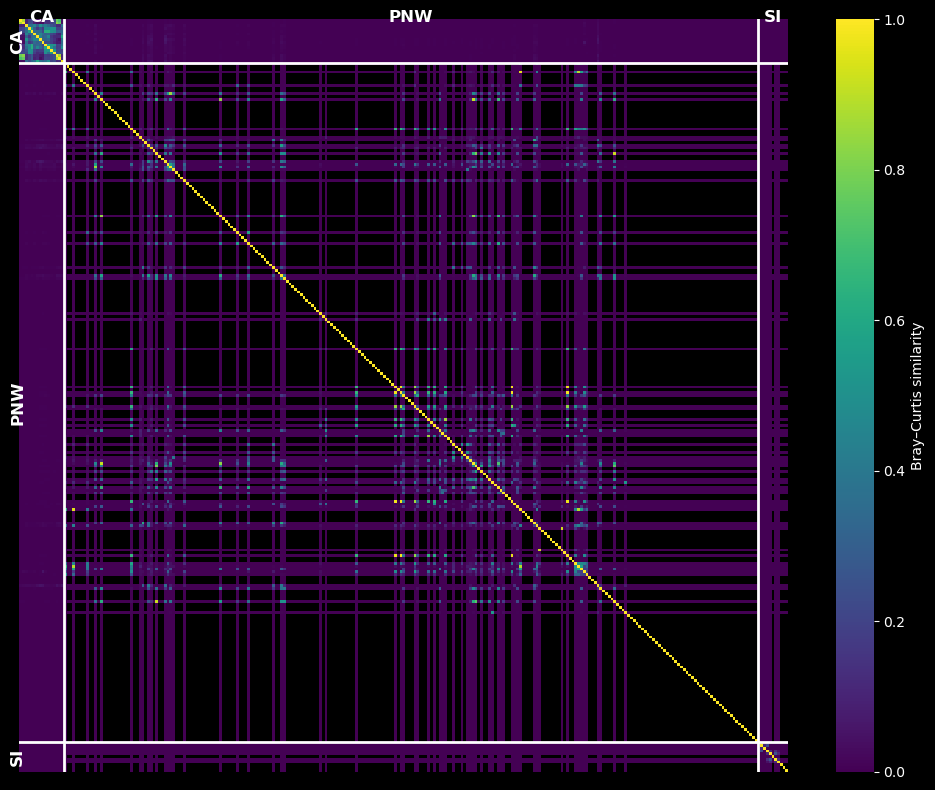

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# ---- Prepare site matrix ordered by project ----
# site_matrix is collapsed abundance per site
site_matrix = (
    df_merged
    .groupby("Site")[asv_cols].sum()
    .merge(df_merged[["Site", "Project"]].drop_duplicates(), on="Site")
    .sort_values(["Project", "Site"])
    .set_index("Site")[asv_cols]
)

# Compute Bray–Curtis similarity
bray = pdist(site_matrix.values, metric="braycurtis")
similarity = 1 - squareform(bray)

# ---- Compute project block positions ----
proj_info = (
    df_merged[["Site", "Project"]]
    .drop_duplicates()
    .set_index("Site")
    .loc[site_matrix.index]  # ensure same ordering
)

# How many sites per project in heatmap order
project_sizes = proj_info["Project"].value_counts()[proj_info["Project"].unique()]

# Get the block boundaries (cumulative sizes)
block_positions = np.cumsum(project_sizes)[:-1]

# Centers for labeling
centers = block_positions.copy()
centers = np.insert(centers, 0, 0)
centers = centers + np.array(project_sizes)/2

# ---- Plot heatmap without labels ----
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    similarity,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Bray–Curtis similarity"}
)

# ---- Draw project separation lines ----
for pos in block_positions:
    ax.axhline(pos, color="white", linewidth=2)
    ax.axvline(pos, color="white", linewidth=2)

# ---- Add project labels centered on blocks ----
for center, project in zip(centers, project_sizes.index):
    # X-axis label
    ax.text(center, -0.7, project,
            ha="center", va="center",
            fontsize=12, fontweight="bold")

    # Y-axis label
    ax.text(-0.7, center, project,
            ha="center", va="center",
            fontsize=12, fontweight="bold", rotation=90)

#plt.title("Bray–Curtis Similarity of Raw Reads (Grouped by Project)")
plt.tight_layout()
plt.show()
